In [1]:
# Import all relevant packages for this notebook
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from mplsoccer import Pitch
import socceraction.spadl.config as spadlcfg
import re

# Prior Shift

In [2]:
data_path = Path().resolve().parent / "data" / "vaep_data" / "all_leagues_vaep.h5"
data = pd.HDFStore(str(data_path), mode="r")
full_data = data.vaep_data.copy()

actiontype_map = dict(enumerate(spadlcfg.actiontypes))
full_data["type_name"] = full_data["type_id"].map(actiontype_map).fillna("unknown")

In [3]:
# [print(i) for i in full_data.columns]

In [4]:
def _season_start_year(s):
    m = re.search(r"(\d{4})", str(s))
    return int(m.group(1)) if m else 9999

# selected_league = "La Liga"  # Change this to analyze another league
# league_data = full_data.loc[full_data["competition_name"] == selected_league].copy()

home_col, away_col = "home_score", "away_score"
per_game = full_data.groupby(["season_name", "competition_name", "game_id"])[[home_col, away_col]].max().sum(axis=1).rename("goals")
per_game.head()

season_name  competition_name  game_id
1958         FIFA World Cup    3888704    7
                               3888705    7
1962         FIFA World Cup    3888854    2
1970         FIFA World Cup    3888699    5
                               3888700    1
Name: goals, dtype: int64

In [5]:
min_games = 30
season_goals = per_game.groupby(["season_name", "competition_name"]).agg(["count", "mean", "std"]).fillna(0).reset_index()
season_goals.columns = ["season_name", "competition_name", "num_games", "avg_goals_per_game", "std_goals_per_game"]

season_goals = season_goals[season_goals["num_games"] >= min_games].copy()
season_goals["season_sort"] = season_goals["season_name"].apply(_season_start_year)
season_goals = season_goals.sort_values("season_sort").reset_index(drop=True)

lower, upper=2010,2021
season_goals = season_goals[(season_goals["season_sort"] >= lower) & (season_goals["season_sort"] <= upper)].copy()


In [6]:
focus_leagues = [
    "FA Women's Super League",
    "La Liga",
    "Premier League",
    "Serie A",
    "1. Bundesliga",
    "Ligue 1",
]

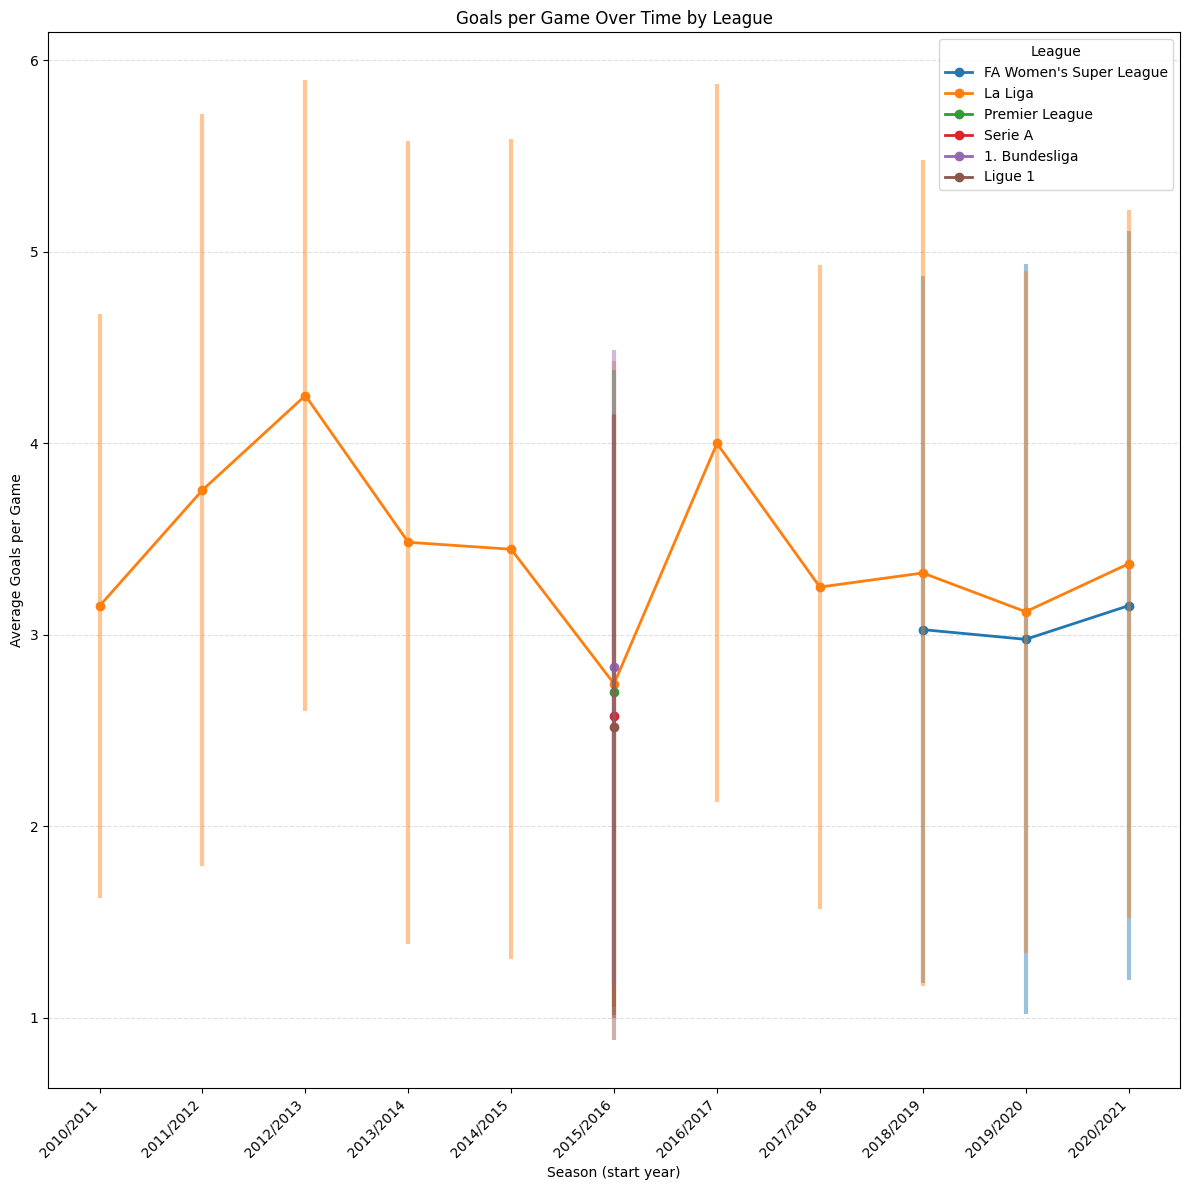

In [7]:
# Filter for focus_leagues and sort by season
plot_df = season_goals[season_goals["competition_name"].isin(focus_leagues)].copy()
plot_df = plot_df.sort_values(["competition_name", "season_sort"])

fig, ax = plt.subplots(figsize=(12, 12))
colors = plt.cm.tab10.colors

for i, league in enumerate(focus_leagues):
    league_df = plot_df[plot_df["competition_name"] == league]
    if league_df.empty:
        continue
    # Use season_sort for x, season_name for labels
    ax.plot(
        league_df["season_sort"],
        league_df["avg_goals_per_game"],
        label=league,
        color=colors[i % len(colors)],
        marker="o",
        linewidth=2,
    )
    # Plot standard deviation as a vertical line segment (not a filled bar)
    ax.vlines(
        league_df["season_sort"],
        league_df["avg_goals_per_game"] - league_df["std_goals_per_game"],
        league_df["avg_goals_per_game"] + league_df["std_goals_per_game"],
        color=colors[i % len(colors)],
        alpha=0.45,
        linewidth=3,
    )

# Set x-ticks to season_sort and labels to season_name (unique and sorted)
unique_seasons = plot_df.drop_duplicates("season_sort").sort_values("season_sort")
ax.set_xticks(unique_seasons["season_sort"])
ax.set_xticklabels(unique_seasons["season_name"], rotation=45, ha="right")

ax.set_xlabel("Season (start year)")
ax.set_ylabel("Average Goals per Game")
ax.set_title("Goals per Game Over Time by League")
ax.legend(title="League")
ax.grid(axis="y", linestyle="--", alpha=0.4)
# Add a note about the gap between 2020/2021 and 2022/2023 if present
# This is likely due to missing or filtered-out data for the 2021/2022 season in some leagues.
# Check which seasons are present for each league if you want to investigate further.
plt.tight_layout()
plt.show()

In [8]:
season_year = "2015/2016"
top5_ordered = ["Serie A", "La Liga", "1. Bundesliga", "Premier League", "Ligue 1"]

season_data_top5 = full_data.loc[(full_data["season_name"] == season_year) & (full_data["competition_name"].isin(top5_ordered))].copy()

per_game_top5 = season_data_top5.groupby(["competition_name", "game_id"])[["home_score", "away_score"]].max().sum(axis=1).rename("goals_in_game").reset_index()

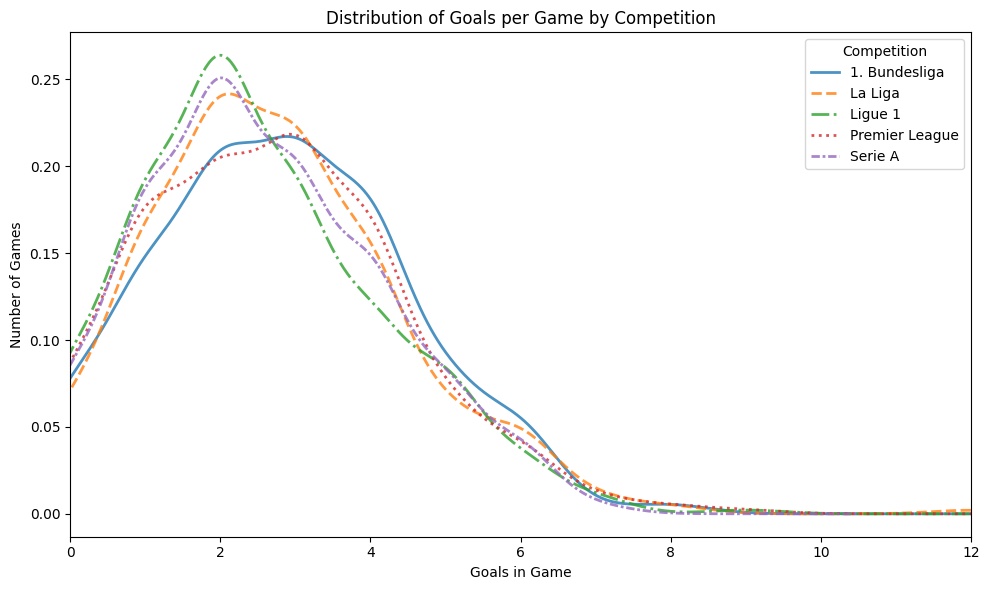

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
linestyles=["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 5))]
for i, league in enumerate(per_game_top5["competition_name"].unique()):
    league_games = per_game_top5[per_game_top5["competition_name"] == league]
    # Plot kernel density estimate instead of histogram
    league_games["goals_in_game"].plot(
        kind="density",
        ax=ax,
        label=league,
        linewidth=2,
        alpha=0.8,
        linestyle=linestyles[i % len(linestyles)]
    )
ax.set_xlim(0,12)
ax.set_xlabel("Goals in Game")
ax.set_ylabel("Number of Games")
ax.set_title("Distribution of Goals per Game by Competition")
ax.legend(title="Competition")
plt.tight_layout()
plt.show()

In [10]:
league_stats = per_game_top5.groupby("competition_name").agg(
    num_games=("game_id", "count"),
    total_goals=("goals_in_game", "sum"),
    avg_goals=("goals_in_game", "mean"),
    std_goals=("goals_in_game", "std"),
).reset_index()

league_stats["std_goals"] = league_stats["std_goals"].fillna(0)
league_stats["competition_name"] = pd.Categorical(league_stats["competition_name"], categories=top5_ordered, ordered=True)
league_stats = league_stats.sort_values("competition_name")


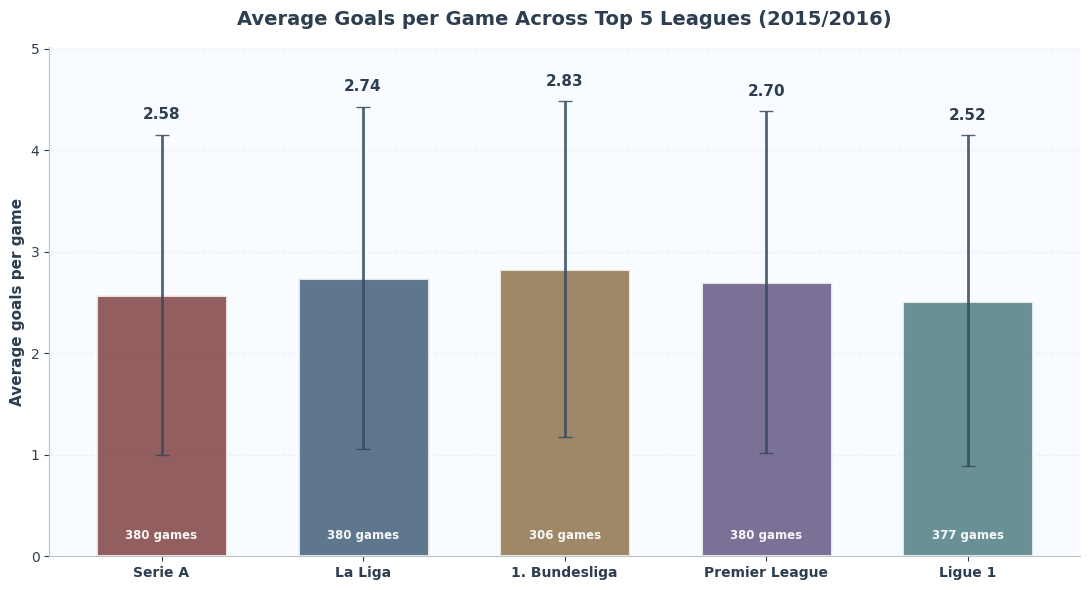

In [11]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.set_facecolor("#f8fbff")
ax.grid(axis="y", linestyle="--", linewidth=0.9, alpha=0.3, color="#d0dce8")
ax.set_axisbelow(True)

league_colors = {
    "Serie A": "#7D3C3C",
    "La Liga": "#3D5A73",
    "1. Bundesliga": "#8B6F47",
    "Premier League": "#5F5380",
    "Ligue 1": "#4A7A7E",
}

colors = [league_colors[league] for league in league_stats["competition_name"]]

bars = ax.bar(
    range(len(league_stats)),
    league_stats["avg_goals"],
    yerr=league_stats["std_goals"],
    color=colors,
    alpha=0.82,
    edgecolor="white",
    linewidth=2.2,
    error_kw={"elinewidth": 2.0, "capsize": 5, "ecolor": "#34495e", "alpha": 0.85},
    width=0.65,
)

for i, (bar, row) in enumerate(zip(bars, league_stats.itertuples())):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + row.std_goals + 0.12,
        f"{row.avg_goals:.2f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="#2c3e50",
    )
    # Game count label in the middle of bar.
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        0.2, #height / 2,
        f"{int(row.num_games)} games",
        ha="center",
        va="center",
        fontsize=8.5,
        color="white",
        fontweight="bold",
        alpha=0.95,
    )

ax.set_xticks(range(len(league_stats)))
ax.set_xticklabels(
    league_stats["competition_name"],
    fontsize=11,
    fontweight="semibold",
    rotation=0,
)

ax.set_title(
    f"Average Goals per Game Across Top 5 Leagues ({season_year})",
    fontsize=14,
    fontweight="bold",
    pad=16,
    color="#2c3e50",
)
ax.set_ylabel("Average goals per game", fontsize=11, fontweight="semibold", color="#2c3e50")

y_max = league_stats["avg_goals"].max() + league_stats["std_goals"].max() + 0.5
ax.set_ylim(0, y_max)

# Clean up spines.
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#bdc3c7")
ax.spines["bottom"].set_color("#bdc3c7")
ax.tick_params(axis="both", which="major", labelsize=10, colors="#2c3e50")

plt.tight_layout()
plt.show()

# Concept Shift

In [12]:
def mark_true_goal_actions(df):
    out = df.copy()

    sort_cols = [c for c in ["game_id", "period_id", "time_seconds", "action_id"] if c in out.columns]
    out = out.sort_values(sort_cols).copy()
    is_true_goal_action = pd.Series(False, index=out.index)

    if not is_true_goal_action.any():
        shot_like_actions = {"shot", "shot_penalty", "shot_freekick"}
        is_shot_like = out["type_name"].astype(str).isin(shot_like_actions) if "type_name" in out.columns else pd.Series(False, index=out.index)

        if "result_name" in out.columns:
            is_goal_result = out["result_name"].astype(str).isin({"success", "owngoal"})
            is_true_goal_action = is_shot_like & is_goal_result
        elif "result_id" in out.columns:
            is_true_goal_action = is_shot_like & out["result_id"].eq(1)

    out["is_true_goal_action"] = is_true_goal_action.fillna(False)
    return out


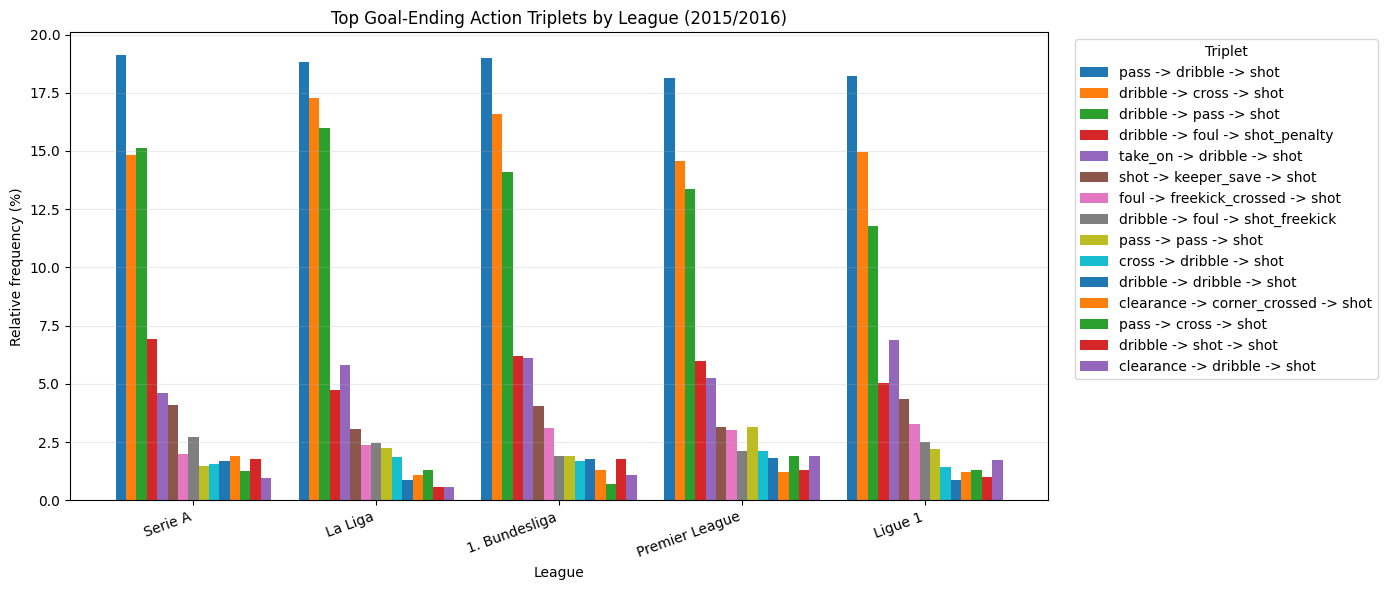

In [ ]:
selected_season = "2015/2016"

top5_leagues = [
    "Serie A",
    "La Liga",
    "1. Bundesliga",
    "Premier League",
    "Ligue 1",
]

triplet_data = full_data.loc[
    full_data["season_name"].astype(str).eq(selected_season)
    & full_data["competition_name"].isin(top5_leagues)
].copy()


# Ensure correct temporal order inside each game before creating lagged actions.
order_cols = [c for c in ["game_id", "period_id", "time_seconds", "action_id"] if c in triplet_data.columns]
triplet_data = triplet_data.sort_values(order_cols).copy()
triplet_data = mark_true_goal_actions(triplet_data)

triplet_data["type_t-1"] = triplet_data.groupby("game_id")["type_name"].shift(1)
triplet_data["type_t-2"] = triplet_data.groupby("game_id")["type_name"].shift(2)

goal_triplets = triplet_data.loc[
    triplet_data["is_true_goal_action"]
    & triplet_data["type_t-1"].notna()
    & triplet_data["type_t-2"].notna()
].copy()

goal_triplets["triplet"] = (
    goal_triplets["type_t-2"] + " -> " + goal_triplets["type_t-1"] + " -> " + goal_triplets["type_name"]
)

triplet_counts = (
    goal_triplets.groupby(["competition_name", "triplet"]).size().rename("count").reset_index()
)
triplet_counts["share_%"] = (
    triplet_counts.groupby("competition_name")["count"]
    .transform(lambda x: 100 * x / x.sum())
    .round(3)
)

triplet_cmp = (
    triplet_counts.pivot_table(
        index="triplet",
        columns="competition_name",
        values="share_%",
        fill_value=0,
    )
    .reindex(columns=top5_leagues, fill_value=0)
)
triplet_cmp = triplet_cmp.loc[triplet_cmp.mean(axis=1).sort_values(ascending=False).index]

top_n_triplets = 15
plot_table = triplet_cmp.head(top_n_triplets)

fig, ax = plt.subplots(figsize=(14, 6))
plot_table.T.plot(kind="bar", ax=ax, width=0.85)
ax.set_title(f"Top Goal-Ending Action Triplets by League ({selected_season})")
ax.set_xlabel("League")
ax.set_ylabel("Relative frequency (%)")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Triplet", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

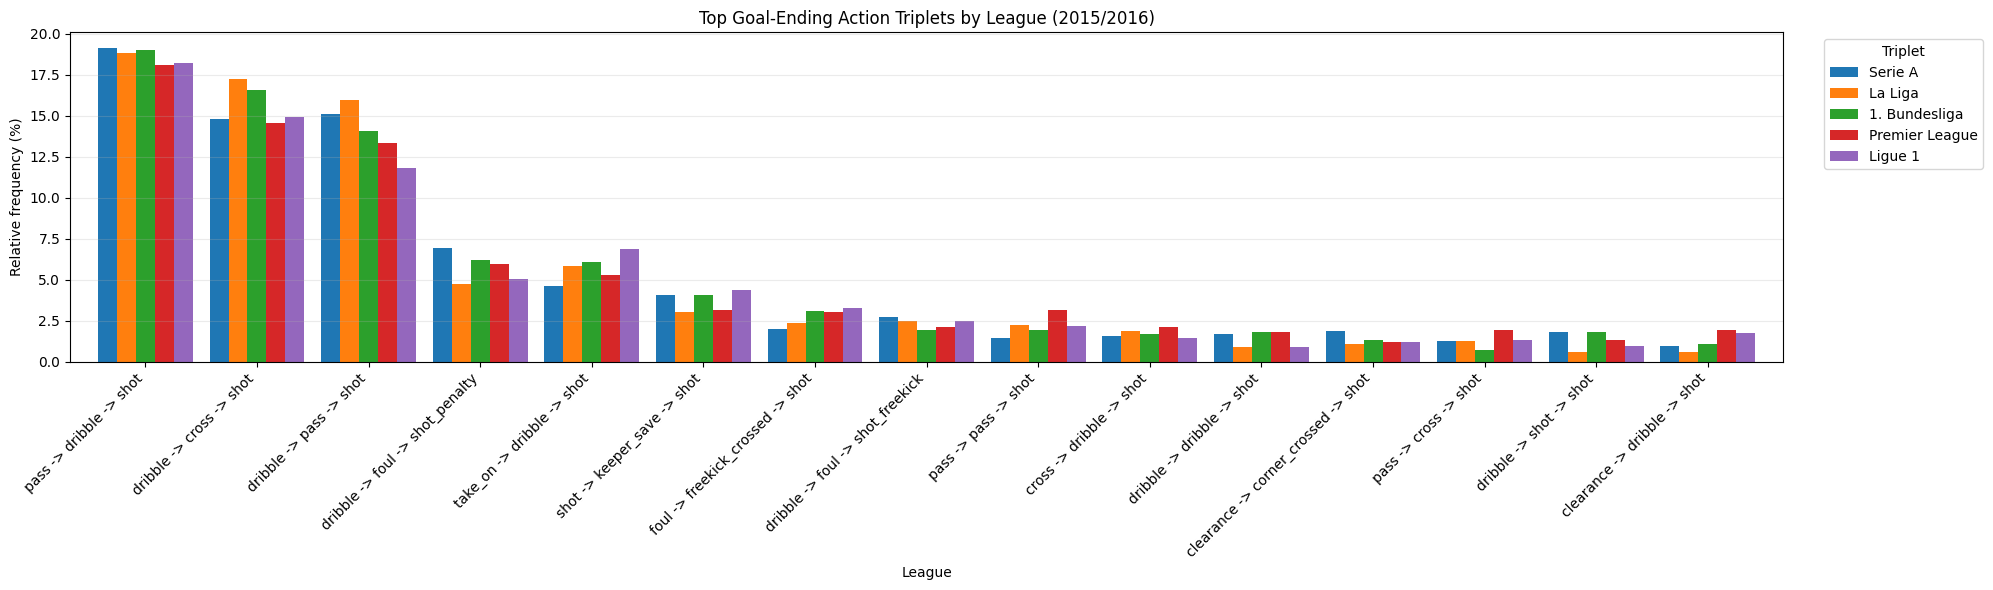

In [14]:
fig, ax = plt.subplots(figsize=(20, 6))
plot_table.plot(kind="bar", ax=ax, width=0.85)
ax.set_title(f"Top Goal-Ending Action Triplets by League ({selected_season})")
ax.set_xlabel("League")
ax.set_ylabel("Relative frequency (%)")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Triplet", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

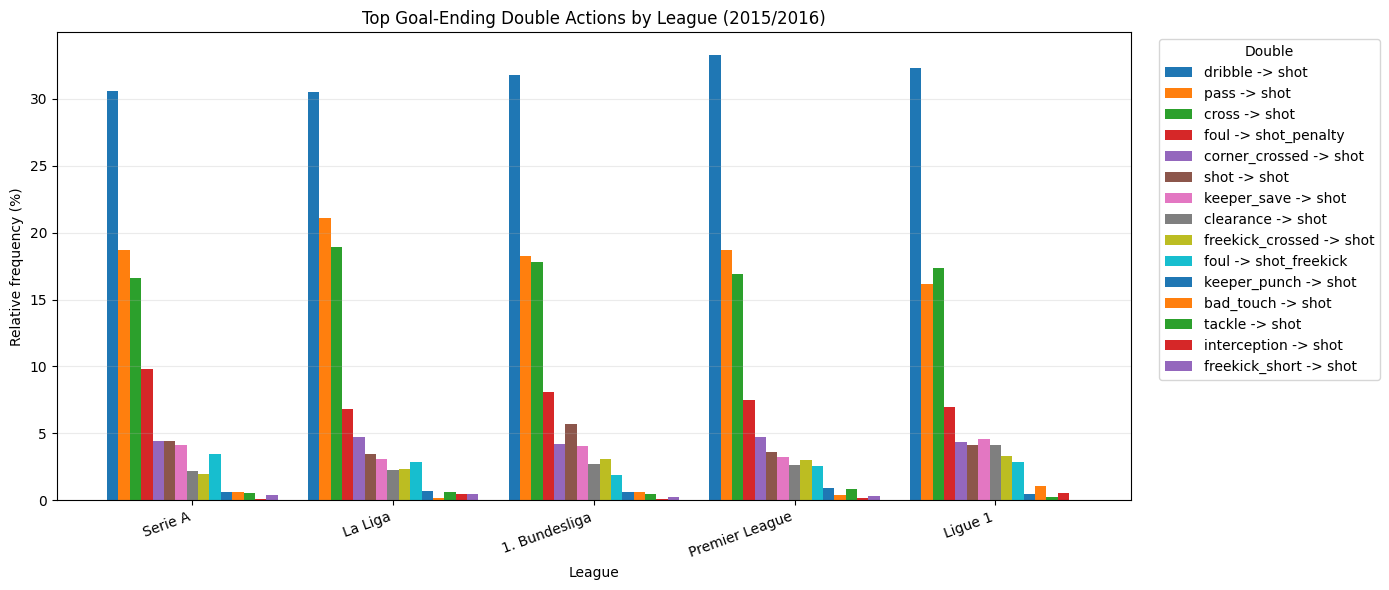

In [15]:
# Goal-ending DOUBLE actions (t-1 -> t) across top-5 leagues for one season
selected_season = "2015/2016"

top5_leagues = [
    "Serie A",
    "La Liga",
    "1. Bundesliga",
    "Premier League",
    "Ligue 1",
]

double_data = full_data.loc[
    full_data["season_name"].astype(str).eq(selected_season)
    & full_data["competition_name"].isin(top5_leagues)
].copy()


if "type_name" not in double_data.columns:
    actiontype_map = dict(enumerate(spadlcfg.actiontypes))
    double_data["type_name"] = double_data["type_id"].map(actiontype_map).fillna("unknown")

order_cols = [c for c in ["game_id", "period_id", "time_seconds", "action_id"] if c in double_data.columns]
double_data = double_data.sort_values(order_cols).copy()
double_data = mark_true_goal_actions(double_data)

double_data["type_t-1"] = double_data.groupby("game_id")["type_name"].shift(1)

goal_doubles = double_data.loc[
    double_data["is_true_goal_action"]
    & double_data["type_t-1"].notna()
].copy()


goal_doubles["double"] = goal_doubles["type_t-1"] + " -> " + goal_doubles["type_name"]

double_counts = (
    goal_doubles.groupby(["competition_name", "double"]).size().rename("count").reset_index())

double_counts["share_%"] = (
    double_counts.groupby("competition_name")["count"]
    .transform(lambda x: 100 * x / x.sum())
    .round(3)
)

double_cmp = (
    double_counts.pivot_table(
        index="double",
        columns="competition_name",
        values="share_%",
        fill_value=0,
    )
    .reindex(columns=top5_leagues, fill_value=0)
)
double_cmp = double_cmp.loc[double_cmp.mean(axis=1).sort_values(ascending=False).index]

# print(f"Goal-ending DOUBLE share (%) by league for season {selected_season}")
# display(double_cmp.round(3))

top_n_doubles = 15
plot_double = double_cmp.head(top_n_doubles)

fig, ax = plt.subplots(figsize=(14, 6))
plot_double.T.plot(kind="bar", ax=ax, width=0.85)
ax.set_title(f"Top Goal-Ending Double Actions by League ({selected_season})")
ax.set_xlabel("League")
ax.set_ylabel("Relative frequency (%)")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Double", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

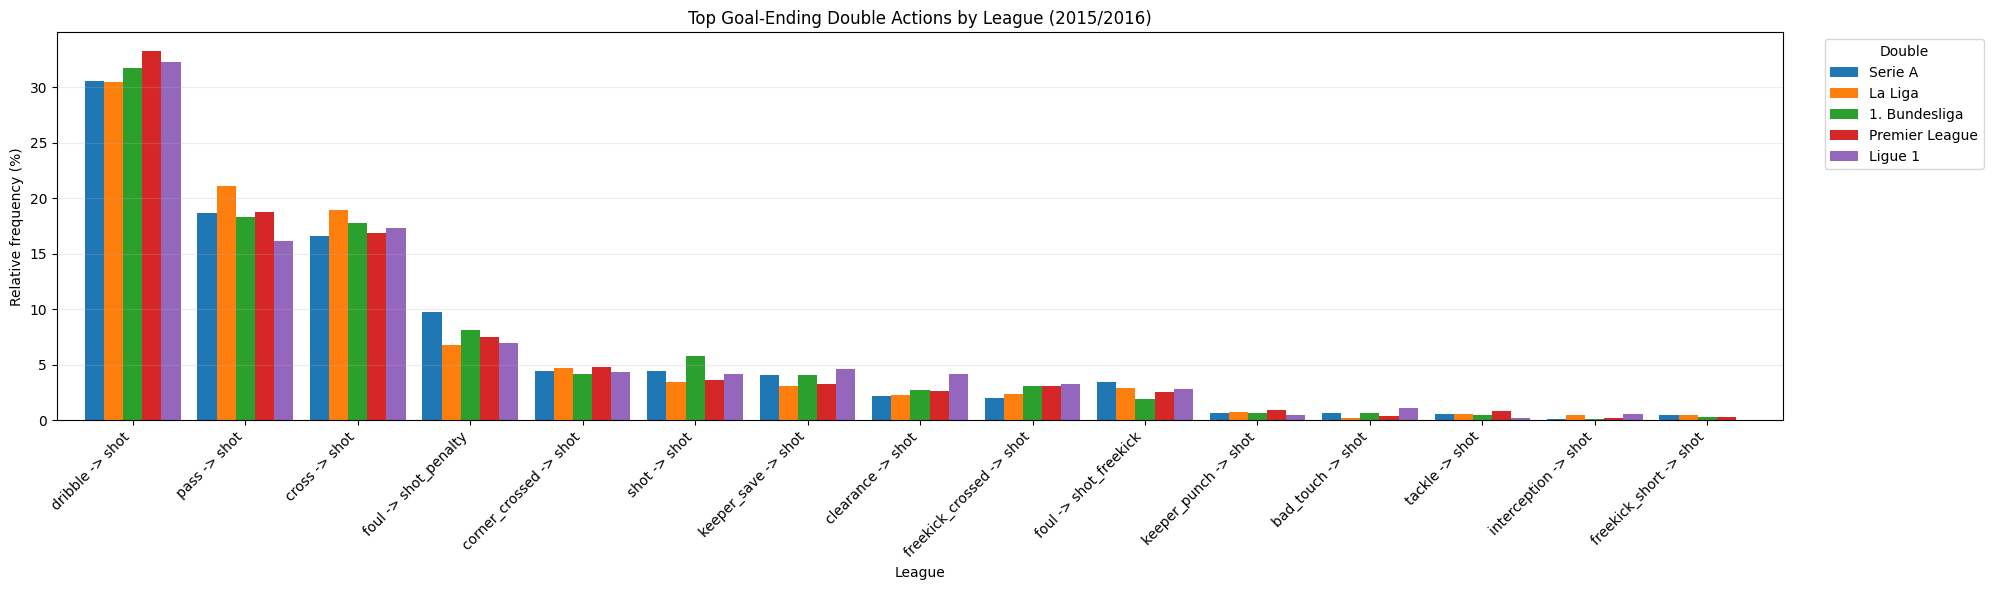

In [16]:
fig, ax = plt.subplots(figsize=(20, 6))
plot_double.plot(kind="bar", ax=ax, width=0.85)
ax.set_title(f"Top Goal-Ending Double Actions by League ({selected_season})")
ax.set_xlabel("League")
ax.set_ylabel("Relative frequency (%)")
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Double", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Covariate Shift